In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [6]:
X = df.drop(columns = ["Survived"])
y = df["Survived"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


In [8]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [9]:
X_train.isnull().mean()


Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [10]:
mean_age = X_train["Age"].mean()
median_age = X_train["Age"].median()
mean_fare = X_train["Fare"].mean()
median_fare = X_train["Fare"].median()

In [12]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [14]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
298,NaN,30.5000,0,28.0,29.498846,30.5000,30.5000
169,28.0,56.4958,0,28.0,28.000000,56.4958,56.4958
587,60.0,79.2000,2,60.0,60.000000,79.2000,79.2000
444,NaN,8.1125,0,28.0,29.498846,8.1125,8.1125
593,NaN,7.7500,2,28.0,29.498846,7.7500,7.7500


In [15]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variable variance after mean imputation: ', X_train['Age_mean'].var())
print('Age variable variance after median imputation: ', X_train['Age_median'].var())
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after mean imputation: ', X_train['Fare_mean'].var())
print('Fare variance after median imputation: ', X_train['Fare_median'].var())

Original Age variable variance:  210.2517072477438
Age variable variance after mean imputation:  168.8519336687225
Age variable variance after median imputation:  169.20731007048096
Original Fare variable variance:  2761.031434948639
Fare variance after mean imputation:  2621.2323749512393
Fare variance after median imputation:  2637.01248167777


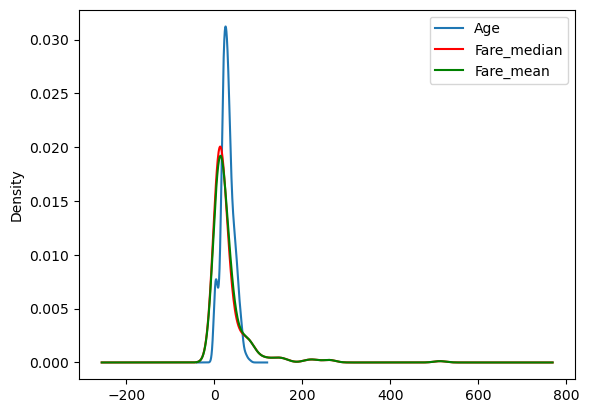

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Age'].plot(kind = 'kde', ax = ax)
#variable imputed with the median
X_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')
#variable imputed with the mean
X_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')
#add legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')

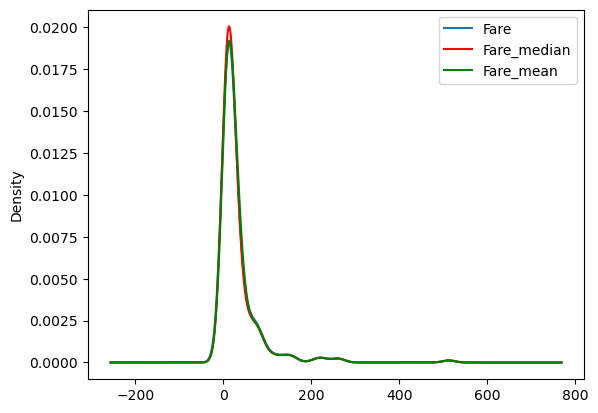

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Fare'].plot(kind = 'kde', ax = ax)
#variable imputed with the median
X_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')
#variable imputed with the mean
X_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')
#add legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')

In [18]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [19]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Fare_median,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

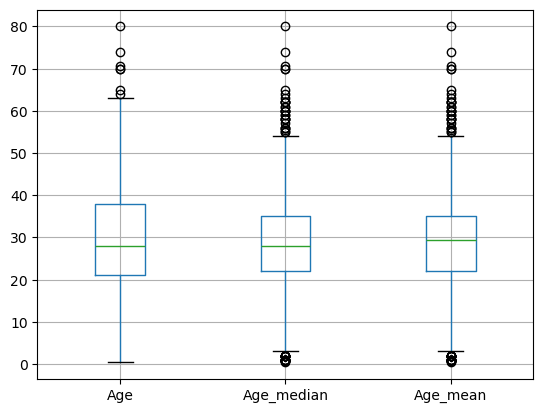

In [20]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

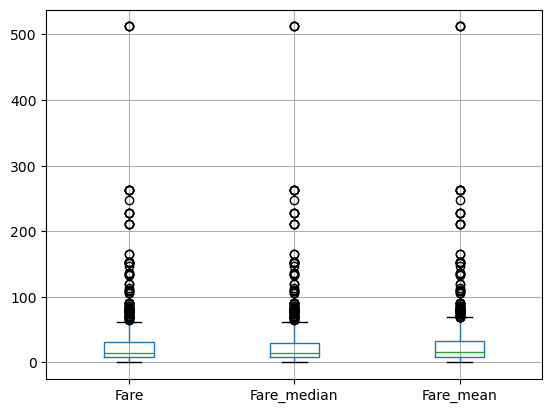

In [21]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

In [22]:
#using sklearn
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =2)

In [23]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')

In [24]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder = 'passthrough')

In [25]:
trf.fit(X_train)

c:\Users\Anamika Gupta\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [26]:
trf.fit(X_train)

c:\Users\Anamika Gupta\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [27]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [28]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)
X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [29]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after 99 imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 imputation: ', X_train['Age_minus1'].var())
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after 999 imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 imputation: ', X_train['Fare_minus1'].var())

Original Age variable variance:  204.3495133904614
Age Variance after 99 imputation:  951.7275570187172
Age Variance after -1 imputation:  318.0896202624484
Original Fare variable variance:  2448.197913706318
Fare Variance after 999 imputation:  47219.20265217623
Fare Variance after -1 imputation:  2378.5676784883503
